=============================================================================
Notebook 03: Layer 2 — Underlying Determinants
Global Nutrition Monitoring Framework — UNICEF Conceptual Framework Project
Adam T. Bailes, MPH | August 2026
=============================================================================

PURPOSE
-------
Analyze indicators across the three dimensions of underlying determinants
in the UNICEF 2020 Conceptual Framework:
  - Food (food security, dietary diversity)
  - Care/Practices (IYCF indicators, feeding practices)
  - Services (ANC, SBA, health system reach, programme coverage)

This notebook also produces the cross-layer correlation analysis linking
underlying determinants to nutrition outcomes.
=============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PROC = '../data/processed'
FIGURES   = '../outputs/figures'
TABLES    = '../outputs/tables'

In [3]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

In [4]:
UNICEF_BLUE   = '#1CABE2'
UNICEF_NAVY   = '#374EA2'
UNICEF_GREEN  = '#00833D'
UNICEF_ORANGE = '#F26A21'

In [5]:
print("=" * 70)
print("NOTEBOOK 03: LAYER 2 — UNDERLYING DETERMINANTS")
print("=" * 70)

NOTEBOOK 03: LAYER 2 — UNDERLYING DETERMINANTS


In [6]:
df = pd.read_csv(f'{DATA_PROC}/unicef_sdmx_clean.csv')
df_latest = pd.read_csv(f'{DATA_PROC}/latest_values_by_country.csv')

--- Indicator groupings by conceptual framework dimension ---

In [7]:
IYCF_CODES = {
    'NT_BF_EIBF':    'Early Initiation of BF',
    'NT_BF_EXBF':    'Exclusive BF <6m',
    'NT_BF_CBF12_23':'Continued BF 12-23m',
    'NT_CF_MDD':     'Minimum Dietary Diversity',
    'NT_CF_MMF':     'Minimum Meal Frequency',
    'NT_CF_MAD':     'Minimum Acceptable Diet',
}

In [8]:
SERVICES_CODES = {
    'MNCH_ANC4':    'ANC 4+ Visits',
    'MNCH_SAB':     'Skilled Birth Attendance',
    'IM_DTP3':      'DTP3 Immunisation',
    'NT_SAM_TR':    'SAM Treatment Coverage',
    'NT_VAS_12_59': 'Vitamin A Supplementation',
}

In [9]:
ALL_L2 = {**IYCF_CODES, **SERVICES_CODES}

=============================================================================
FIGURE 4: IYCF indicator dashboard — global and regional
=============================================================================

In [10]:
print("\n[1] Generating IYCF indicator dashboard...")


[1] Generating IYCF indicator dashboard...


In [11]:
df_iycf = df_latest[df_latest['indicator'].isin(IYCF_CODES.keys())].copy()
df_iycf['indicator_short'] = df_iycf['indicator'].map(IYCF_CODES)

In [12]:
# Regional median values
df_iycf_reg = (df_iycf
               .groupby(['region', 'indicator_short'])['value']
               .median()
               .reset_index())

In [13]:
# Global medians
df_iycf_global = (df_iycf
                  .groupby('indicator_short')['value']
                  .median()
                  .reset_index()
                  .rename(columns={'value': 'global_median'}))

Text(0.5, 0.98, 'IYCF Indicators — Regional Coverage Estimates (Most Recent Data)\nUNICEF Conceptual Framework — Layer 2: Underlying Determinants (Diets and Care)')

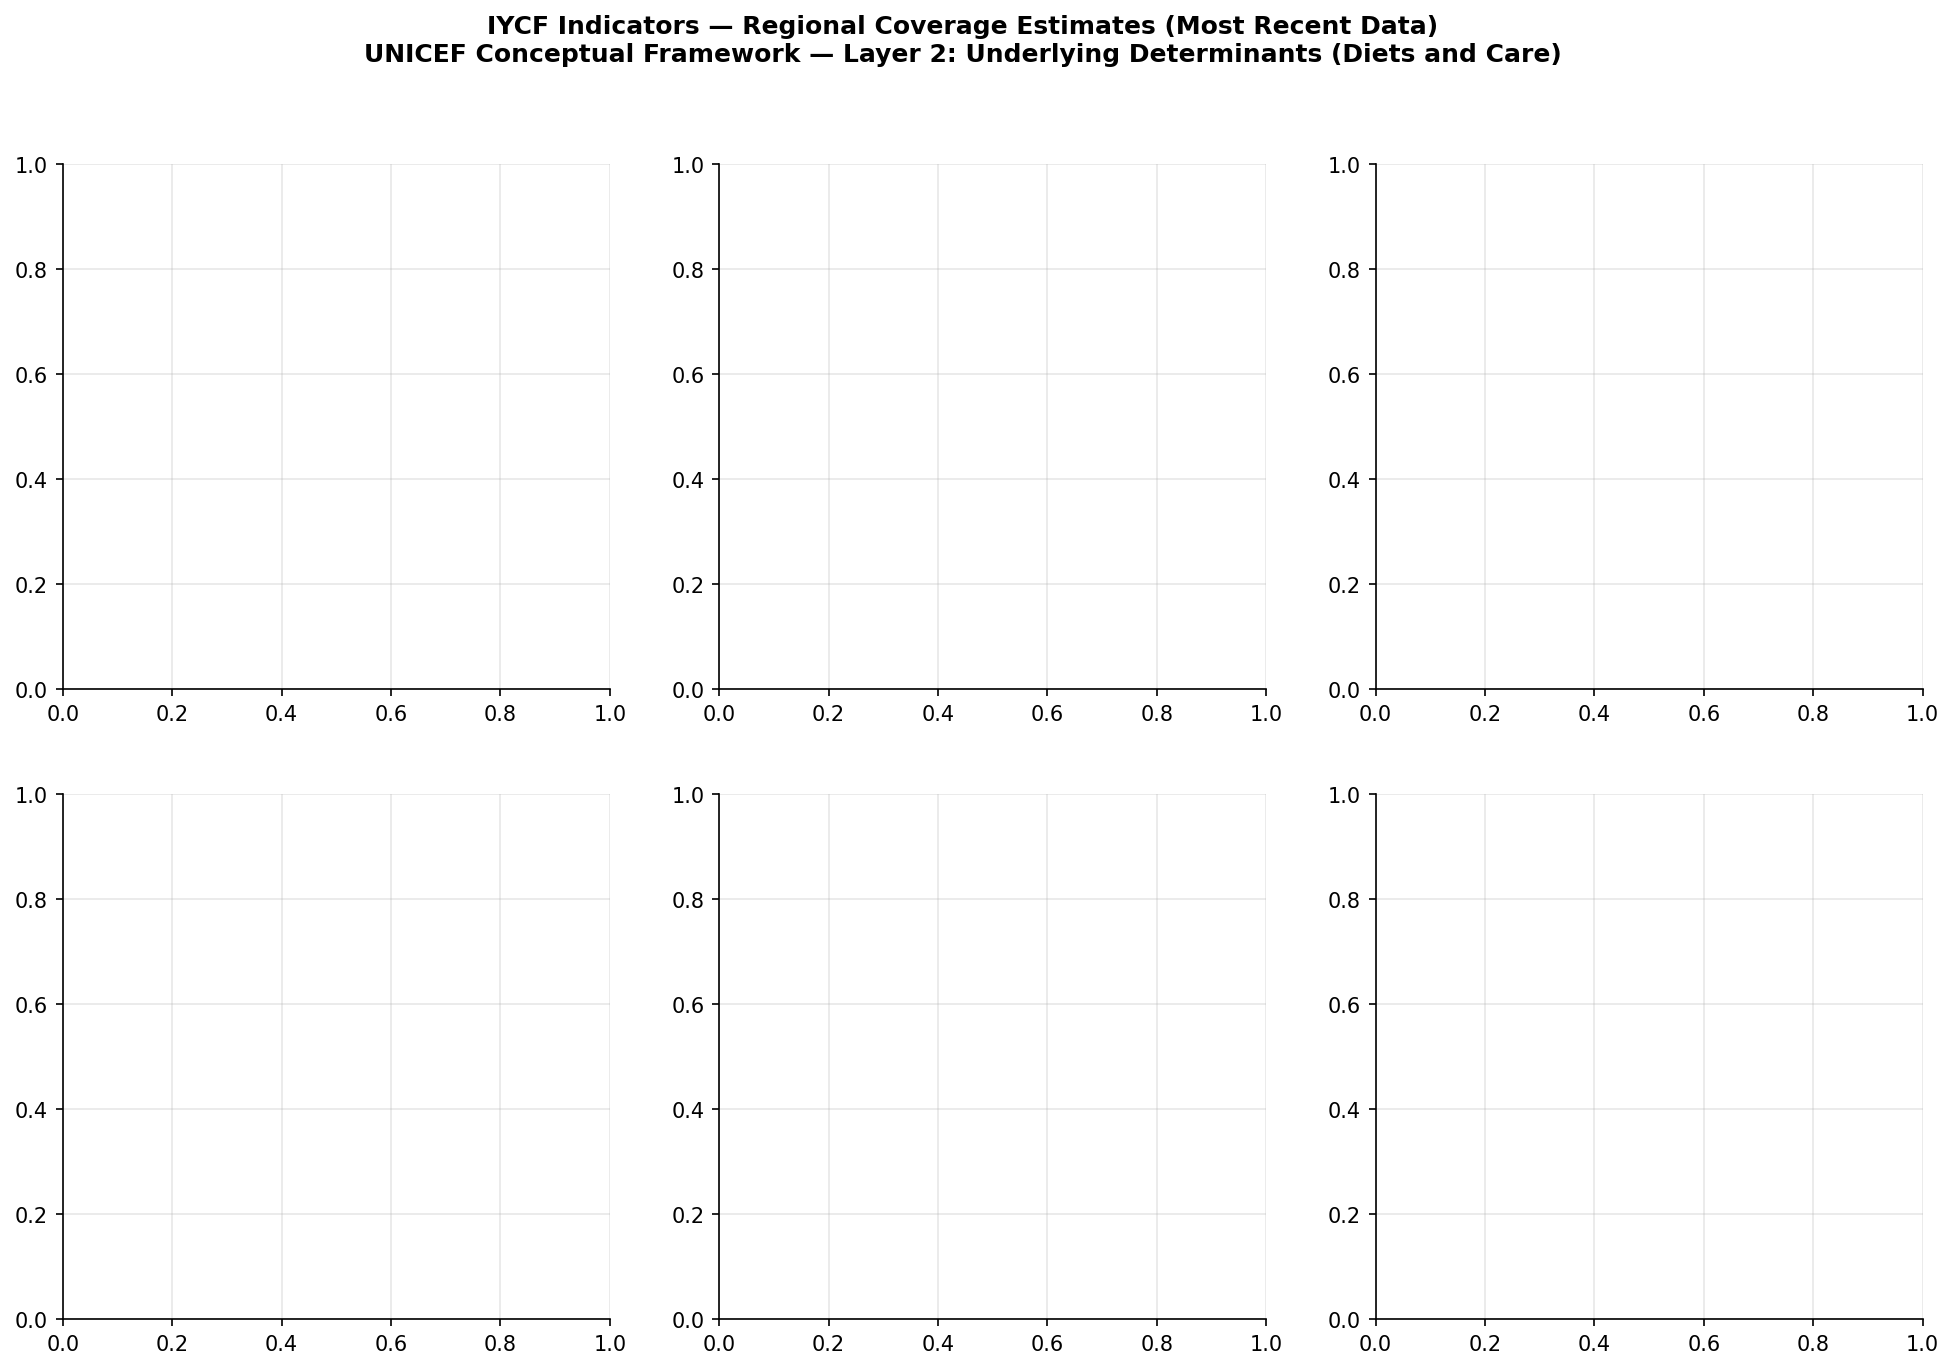

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'IYCF Indicators — Regional Coverage Estimates (Most Recent Data)\n'
    'UNICEF Conceptual Framework — Layer 2: Underlying Determinants (Diets and Care)',
    fontsize=12, fontweight='bold'
)

In [15]:
REGION_COLORS = {
    'Eastern and Southern Africa':  UNICEF_BLUE,
    'West and Central Africa':      UNICEF_ORANGE,
    'South Asia':                   '#6A1E74',
    'East Asia and Pacific':        UNICEF_GREEN,
    'Middle East and North Africa': '#E8A838',
    'Latin America and Caribbean':  '#00AED9',
    'Europe and Central Asia':      '#80BD41',
}

In [16]:
for idx, (code, short) in enumerate(IYCF_CODES.items()):
    ax = axes.flatten()[idx]
    df_ind = df_iycf[df_iycf['indicator'] == code].copy()

    if df_ind.empty:
        ax.text(0.5, 0.5, 'No data available', transform=ax.transAxes,
                ha='center', color='gray')
        ax.set_title(short)
        continue

    # Box plot by region
    regions_with_data = (df_ind.groupby('region')['value']
                         .count()[lambda x: x >= 3].index.tolist())
    df_plot = df_ind[df_ind['region'].isin(regions_with_data)]

    if df_plot.empty:
        ax.text(0.5, 0.5, 'Insufficient data\nby region',
                transform=ax.transAxes, ha='center', color='gray')
        ax.set_title(short)
        continue

    region_order = (df_plot.groupby('region')['value']
                    .median()
                    .sort_values()
                    .index.tolist())

    # Use bar chart of medians instead of boxplot (faster to render)
    medians = [df_plot[df_plot['region'] == r]['value'].median()
               for r in region_order]
    colors_bar = [REGION_COLORS.get(r, '#AAAAAA') for r in region_order]
    ax.barh(range(len(region_order)), medians, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(region_order)))
    ax.set_yticklabels([r.replace(' and ', ' &\n') for r in region_order],
                       fontsize=7)

    # Global median reference line
    glob_med = df_iycf_global[df_iycf_global['indicator_short'] == short]['global_median']
    if len(glob_med) > 0:
        ax.axhline(glob_med.values[0], color='red',
                   linestyle='--', linewidth=1, alpha=0.6,
                   label=f'Global median: {glob_med.values[0]:.1f}%')
        ax.legend(fontsize=7)

    ax.set_title(short, fontweight='bold', fontsize=10)
    ax.set_ylabel('%', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax.set_ylim(0, 105)

In [17]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig04_iycf_regional_dashboard.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig04_iycf_regional_dashboard.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig04_iycf_regional_dashboard.png


=============================================================================
FIGURE 5: Health services coverage radar / bar chart by region
=============================================================================

In [18]:
print("\n[2] Generating health services coverage chart...")


[2] Generating health services coverage chart...


In [19]:
df_svc = df_latest[df_latest['indicator'].isin(SERVICES_CODES.keys())].copy()
df_svc['indicator_short'] = df_svc['indicator'].map(SERVICES_CODES)

In [20]:
df_svc_reg = (df_svc
              .groupby(['region', 'indicator_short'])['value']
              .median()
              .reset_index())

In [21]:
regions_of_interest = [r for r in REGION_COLORS.keys()
                       if r in df_svc_reg['region'].values]

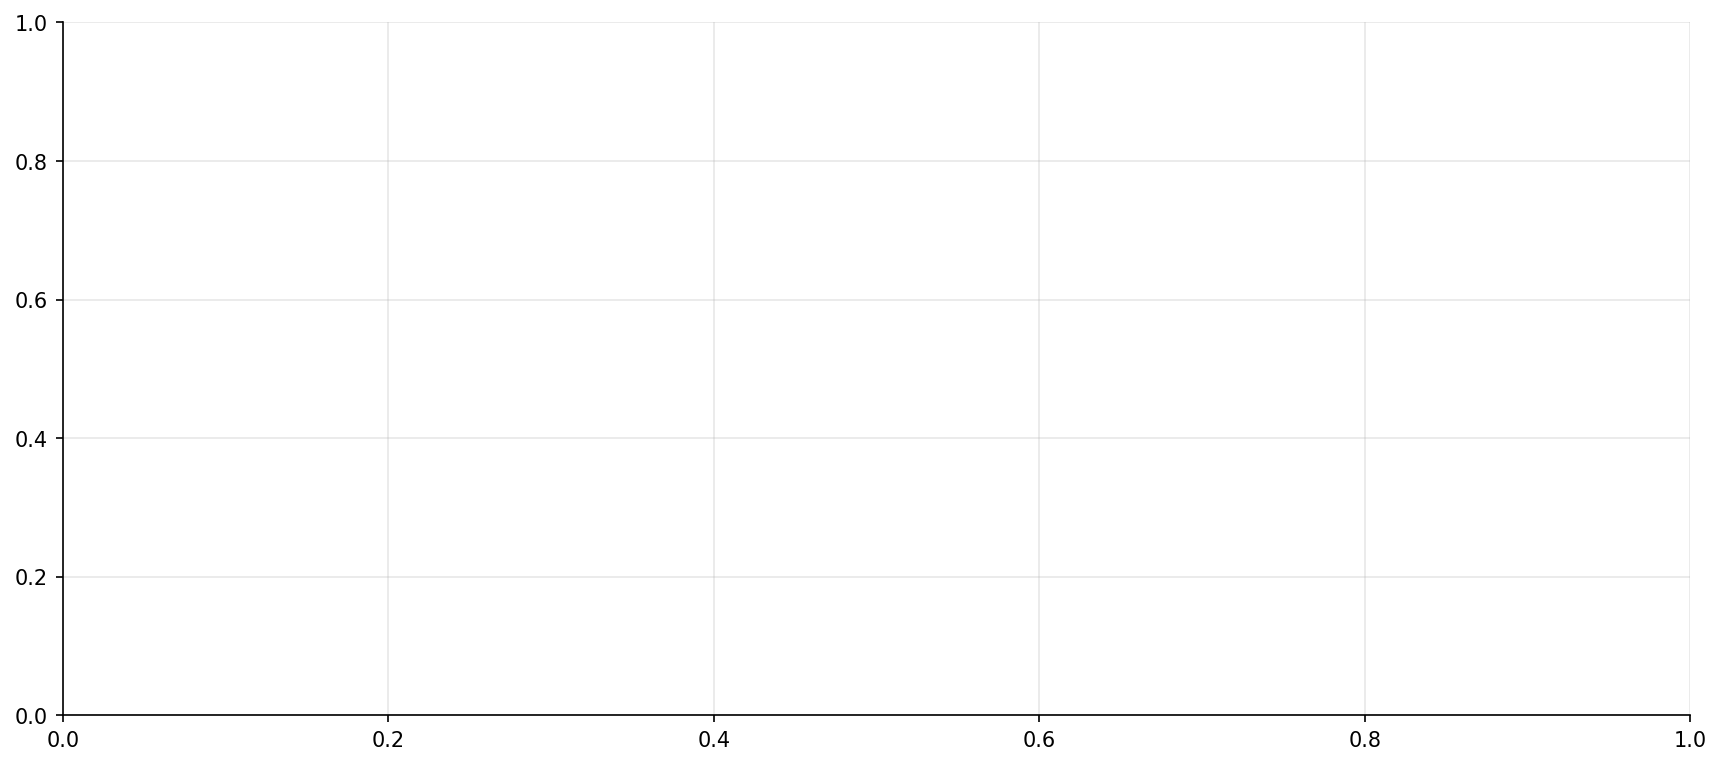

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

In [23]:
x = np.arange(len(SERVICES_CODES))
width = 0.8 / len(regions_of_interest)

In [24]:
for i, region in enumerate(regions_of_interest):
    df_r = df_svc_reg[df_svc_reg['region'] == region]
    vals = [df_r[df_r['indicator_short'] == s]['value'].values
            for s in SERVICES_CODES.values()]
    vals_clean = [v[0] if len(v) > 0 else np.nan for v in vals]

    offset = (i - len(regions_of_interest) / 2) * width + width / 2
    bars = ax.bar(x + offset, vals_clean, width,
                  color=REGION_COLORS.get(region, '#AAAAAA'),
                  alpha=0.85,
                  label=region.replace(' and ', ' & '))

In [25]:
ax.set_xticks(x)
ax.set_xticklabels(list(SERVICES_CODES.values()), rotation=20, ha='right')
ax.set_ylabel('Coverage (%)', fontsize=10)
ax.set_ylim(0, 110)
ax.set_title(
    'Health and Nutrition Services Coverage by Region (Most Recent Data)\n'
    'UNICEF Conceptual Framework — Layer 2: Underlying Determinants (Services)',
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.axhline(80, color='green', linestyle='--', alpha=0.5,
           linewidth=1, label='80% coverage benchmark')

In [26]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig05_services_coverage_by_region.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig05_services_coverage_by_region.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig05_services_coverage_by_region.png


=============================================================================
FIGURE 6: Scatter — EBF vs Stunting (cross-layer relationship)
=============================================================================

In [27]:
print("\n[3] Generating cross-layer correlation: EBF vs Stunting...")


[3] Generating cross-layer correlation: EBF vs Stunting...


In [28]:
df_ebf = (df_latest[df_latest['indicator'] == 'NT_BF_EXBF']
          [['iso3', 'country', 'region', 'income_group', 'value']]
          .rename(columns={'value': 'ebf_pct'}))

In [29]:
df_stunt = (df_latest[df_latest['indicator'] == 'NT_ANT_HAZ_NE2_MOD']
            [['iso3', 'value']]
            .rename(columns={'value': 'stunting_pct'}))

In [30]:
df_cross = df_ebf.merge(df_stunt, on='iso3')

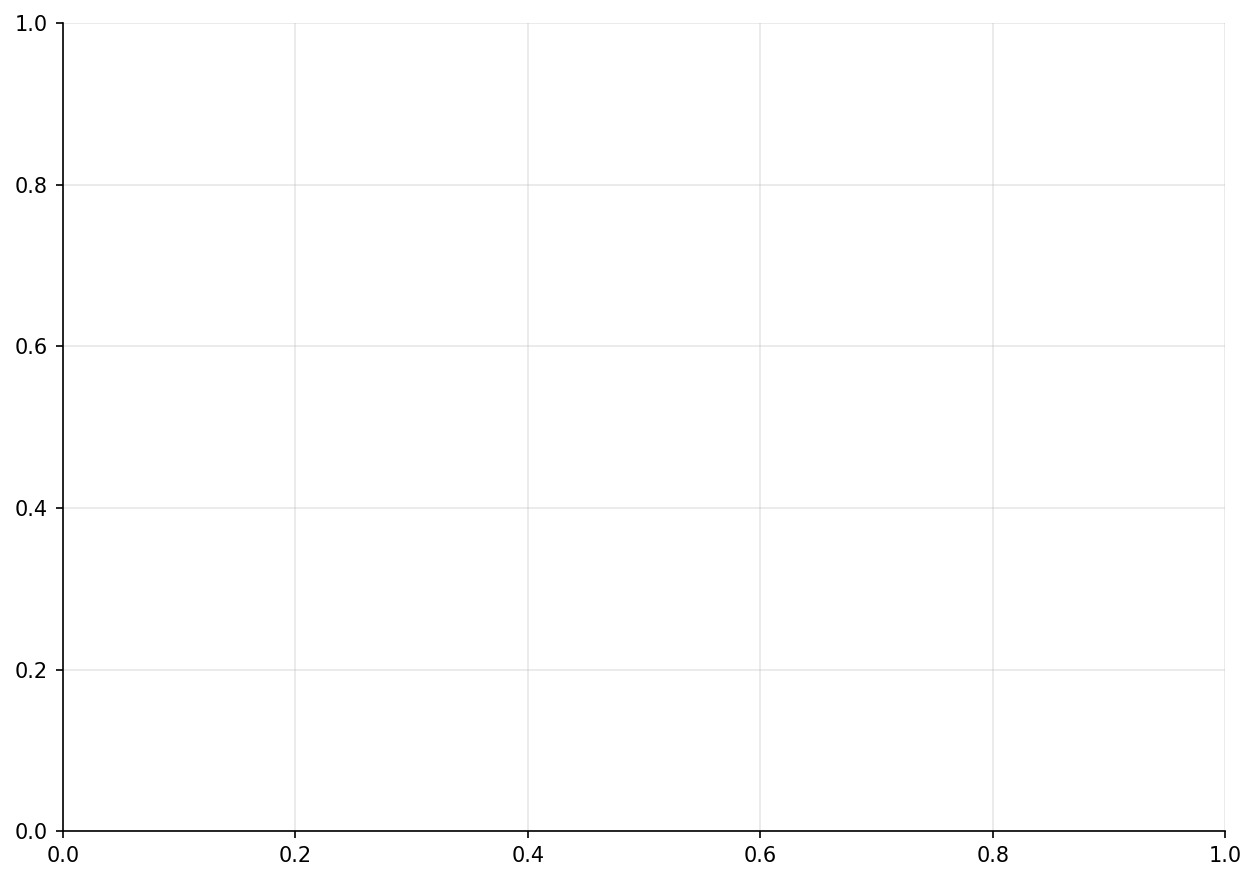

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))

In [32]:
for region, color in REGION_COLORS.items():
    df_r = df_cross[df_cross['region'] == region]
    if len(df_r) >= 2:
        ax.scatter(df_r['ebf_pct'], df_r['stunting_pct'],
                   color=color, alpha=0.7, s=40,
                   label=region.replace(' and ', ' & '), zorder=3)

In [33]:
# Regression line
valid = df_cross.dropna(subset=['ebf_pct', 'stunting_pct'])
if len(valid) >= 10:
    z = np.polyfit(valid['ebf_pct'], valid['stunting_pct'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(valid['ebf_pct'].min(), valid['ebf_pct'].max(), 100)
    ax.plot(x_range, p(x_range), 'k--', alpha=0.4, linewidth=1.5,
            label='Trend line')

    corr = valid['ebf_pct'].corr(valid['stunting_pct'])
    ax.text(0.05, 0.95, f'r = {corr:.2f}',
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

In [34]:
ax.set_xlabel('Exclusive Breastfeeding Rate <6 months (%)', fontsize=11)
ax.set_ylabel('Stunting Prevalence (<-2SD HAZ) (%)', fontsize=11)
ax.set_title(
    'Exclusive Breastfeeding and Stunting: Cross-Layer Relationship\n'
    'UNICEF Conceptual Framework — Layer 1 (Outcome) vs Layer 2 (Determinant)',
    fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig06_cross_layer_ebf_stunting.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig06_cross_layer_ebf_stunting.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig06_cross_layer_ebf_stunting.png


=============================================================================
FIGURE 7: Food security integration (if WFP/FAO data available)
=============================================================================

In [35]:
print("\n[4] Checking food security data availability...")


[4] Checking food security data availability...


In [36]:
fs_sources = {
    'fao_sofi_clean.csv':  'FAO SOFI 2025 (PoU, MDD-C, MDD-W)',
    'wfp_vam_clean.csv':   'WFP VAM (FCS, rCSI)',
    'jmp_wash_clean.csv':  'JMP WASH (water, sanitation)',
}

In [37]:
for filename, label in fs_sources.items():
    path = f'{DATA_PROC}/{filename}'
    if os.path.exists(path):
        df_fs = pd.read_csv(path)
        print(f"  Available: {label} — {len(df_fs):,} rows")
        # Integration code would go here once files are downloaded locally
    else:
        print(f"  Not available (manual download required): {label}")
        print(f"    See 00_data_acquisition.py for download instructions")

  Not available (manual download required): FAO SOFI 2025 (PoU, MDD-C, MDD-W)
    See 00_data_acquisition.py for download instructions
  Not available (manual download required): WFP VAM (FCS, rCSI)
    See 00_data_acquisition.py for download instructions
  Not available (manual download required): JMP WASH (water, sanitation)
    See 00_data_acquisition.py for download instructions


=============================================================================
Export Tableau-ready files
=============================================================================

In [38]:
print("\n[5] Exporting Tableau-ready files...")


[5] Exporting Tableau-ready files...


In [39]:
df_l2_latest = df_latest[df_latest['indicator'].isin(ALL_L2.keys())].copy()
df_l2_latest['indicator_short'] = df_l2_latest['indicator'].map(ALL_L2)
df_l2_latest['l2_dimension'] = df_l2_latest['indicator'].apply(
    lambda x: 'Diets & Care (IYCF)' if x in IYCF_CODES
    else 'Services & Programme Coverage'
)

In [40]:
df_l2_latest.to_csv(f'{TABLES}/tableau_layer2_latest.csv', index=False)
df[df['indicator'].isin(ALL_L2.keys())].to_csv(
    f'{TABLES}/tableau_layer2_trends.csv', index=False)

In [41]:
print("  Saved: tableau_layer2_latest.csv")
print("  Saved: tableau_layer2_trends.csv")
print("\n[DONE] Notebook 03 complete. Run 04_layer3_enabling.py next.")

  Saved: tableau_layer2_latest.csv
  Saved: tableau_layer2_trends.csv

[DONE] Notebook 03 complete. Run 04_layer3_enabling.py next.
